Step 1

Student Depression Dataset

1. What is your data source?

My data source is the Student Depression Dataset, provided as a CSV file. The dataset contains information about students and different factors related to their academic, personal, financial, and mental well-being.

2. Why did you choose it?

I chose this dataset because student mental health is an important topic. The dataset allows us to analyze factors such as academic pressure, sleep, study satisfaction, financial stress, and family history of mental illness and examine their relationship with the depression indicator.

3. What information does it contain?

The dataset contains 27,901 records and 18 columns. Some of the important information includes: Student ID Gender Age City Profession Academic Pressure Work Pressure CGPA Study Satisfaction Job Satisfaction Sleep Duration Dietary Habits Degree Suicidal Thoughts Work/Study Hours Financial Stress Family History of Mental Illness Depression indicator

4. Is it structured, semi-structured, or unstructured?

It is structured data because the information is organized into rows and columns, with each column representing a specific attribute.

5. What format is the data?

The data is in CSV (Comma-Separated Values) format. CSV is a commonly used format for storing and exchanging tabular data and can easily be processed using Python, Pandas, Excel, and SQL.

6. How frequently is the data updated?

The dataset is a static dataset, so it does not appear to be automatically updated on a regular schedule. It represents the data available in the provided CSV file. If a newer version is released by the dataset provider, it would need to be downloaded separately.


STEP 3
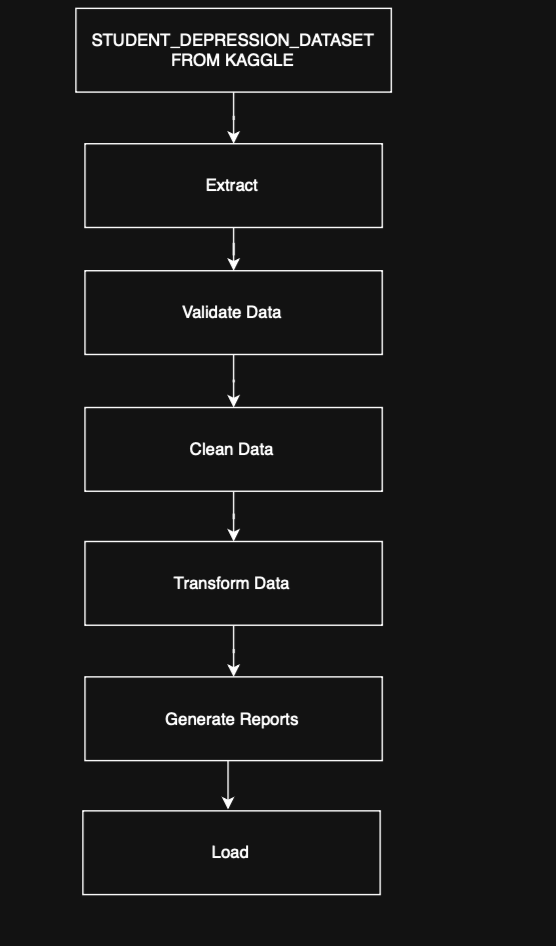

In [ ]:
#Step 5 – Build the Extract Function

In [ ]:
import pandas as pd
import os


In [ ]:
#Step 6 – Build the Transform Function

In [ ]:
def extract():
  file_path = '/content/Mini_Project/raw'
  data= pd.read_csv('/content/Mini_Project/raw/Student Depression Dataset.csv')

 # 2. Display number of records
  print("Number of records:",(data.shape[0]))
    # 3. Display number of columns
  print("Number of columns:", (data.shape[1]))
  return data



In [ ]:
extract()

Number of records: 27901
Number of columns: 18


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [ ]:
def transform(stud_dep):
 # 1. Remove duplicate records
  stud_dep = stud_dep.drop_duplicates()

 # 2. Handle missing values
  stud_dep = stud_dep.dropna()

 # 3. Remove unwanted column
  if "id" in stud_dep.columns:
      stud_dep = stud_dep.drop(columns=["id"])

# 4. Standardize column names
  stud_dep.columns = stud_dep.columns.str.strip().str.lower().str.replace(" ", "_")

# 5. Standardize text values
  for col in stud_dep.select_dtypes(include="object").columns:
        stud_dep[col] = stud_dep[col].str.strip()
# 6. Remove invalid age values
  if "age" in stud_dep.columns:
        stud_dep = stud_dep[(stud_dep["age"] >= 15) & (stud_dep["age"] <= 100)]

# 7. Sort records by age
  if "age" in stud_dep.columns:
        stud_dep = stud_dep.sort_values(by="age")

# 8. Create a depression category
  if "depression" in stud_dep.columns:
        stud_dep["depression_category"] = stud_dep["depression"].map({
            0: "No",
            1: "Yes"
        })
        return stud_dep

In [ ]:
#Step 7 – Generate Reports and
#Step 8 load

In [ ]:
import os

def load(cleaned_data):
  # Create reports directory if it doesn't exist
  reports_dir = '/content/Mini_Project/reports'
  os.makedirs(reports_dir, exist_ok=True)

# 1. Complete cleaned dataset
  cleaned_data.to_csv(os.path.join(reports_dir, 'complete_cleaned_dataset.csv'), index=False)
  print(f"Report saved: {os.path.join(reports_dir, 'complete_cleaned_dataset.csv')}")

# 2. Top 10 records
  top_10_records = cleaned_data.head(10)
  top_10_records.to_csv(os.path.join(reports_dir, 'top_10_records.csv'), index=False)
  print(f"Report saved: {os.path.join(reports_dir, 'top_10_records.csv')}")

# 3. Summary statistics
  summary_stats = cleaned_data.describe()
  summary_stats.to_csv(os.path.join(reports_dir, 'summary_stats.csv'), index=False)

  print(f"Report saved: {os.path.join(reports_dir, 'summary_stats.csv')}")

In [ ]:
#Step 9 – Build the Pipeline

In [ ]:
def run_pipeline():
  raw_data = extract()
  cleaned_data = transform(raw_data)
  load(cleaned_data)

In [ ]:
run_pipeline()

Number of records: 27901
Number of columns: 18
Report saved: /content/Mini_Project/reports/complete_cleaned_dataset.csv
Report saved: /content/Mini_Project/reports/top_10_records.csv
Report saved: /content/Mini_Project/reports/summary_stats.csv


#Preprocessing  data

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
stud_d = pd.read_csv('/content/Mini_Project/reports/complete_cleaned_dataset.csv')
stud_d

,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,work/study_hours,financial_stress,family_history_of_mental_illness,depression,depression_category
0,Female,18.0,Rajkot,Student,5.0,0.0,8.91,3.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,10.0,2.0,Yes,1,Yes
1,Male,18.0,Surat,Student,5.0,0.0,7.83,5.0,0.0,More than 8 hours,Moderate,Class 12,Yes,8.0,5.0,Yes,1,Yes
2,Male,18.0,Vasai-Virar,Student,4.0,0.0,8.70,5.0,0.0,Less than 5 hours,Moderate,Class 12,Yes,2.0,4.0,No,1,Yes
3,Male,18.0,Varanasi,Student,4.0,0.0,9.19,5.0,0.0,7-8 hours,Healthy,Class 12,Yes,12.0,3.0,Yes,1,Yes
4,Female,18.0,Kanpur,Student,1.0,0.0,7.27,5.0,0.0,Less than 5 hours,Healthy,Class 12,No,7.0,5.0,No,1,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27893,Female,51.0,Bhopal,Student,2.0,0.0,8.26,3.0,0.0,Less than 5 hours,Moderate,MBBS,Yes,5.0,5.0,Yes,0,No
27894,Male,54.0,Agra,Student,5.0,0.0,9.60,2.0,0.0,More than 8 hours,Unhealthy,B.Ed,Yes,9.0,3.0,Yes,0,No
27895,Female,56.0,Ludhiana,Student,3.0,0.0,7.94,5.0,0.0,5-6 hours,Unhealthy,BSc,No,1.0,5.0,Yes,0,No
27896,Female,58.0,Chennai,Student,4.0,0.0,8.58,1.0,0.0,7-8 hours,Healthy,Class 12,No,4.0,4.0,No,0,No


In [ ]:
stud_d .shape

(27898, 18)

In [ ]:
stud_d .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27898 entries, 0 to 27897
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 27898 non-null  object 
 1   age                                    27898 non-null  float64
 2   city                                   27898 non-null  object 
 3   profession                             27898 non-null  object 
 4   academic_pressure                      27898 non-null  float64
 5   work_pressure                          27898 non-null  float64
 6   cgpa                                   27898 non-null  float64
 7   study_satisfaction                     27898 non-null  float64
 8   job_satisfaction                       27898 non-null  float64
 9   sleep_duration                         27898 non-null  object 
 10  dietary_habits                         27898 non-null  object 
 11  de

In [ ]:
stud_d .describe()

,age,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,work/study_hours,financial_stress,depression
count,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000
mean,25.822174,3.141336,0.000430,7.656160,2.943974,0.000681,7.156570,3.139867,0.585526
std,4.905651,1.381462,0.043994,1.470708,1.361122,0.044397,3.707598,1.437347,0.492640
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [ ]:
stud_d.nunique()

,0
gender,2
age,34
city,52
profession,14
academic_pressure,6
work_pressure,3
cgpa,332
study_satisfaction,6
job_satisfaction,5
sleep_duration,5


#Check Missing values

In [ ]:
stud_d.isna().sum()

,0
gender,0
age,0
city,0
profession,0
academic_pressure,0
work_pressure,0
cgpa,0
study_satisfaction,0
job_satisfaction,0
sleep_duration,0


In [ ]:
#the data set have no missing values

#Checking outlier

In [ ]:
stud_d.columns

Index(['gender', 'age', 'city', 'profession', 'academic_pressure',
       'work_pressure', 'cgpa', 'study_satisfaction', 'job_satisfaction',
       'sleep_duration', 'dietary_habits', 'degree',
       'have_you_ever_had_suicidal_thoughts_?', 'work/study_hours',
       'financial_stress', 'family_history_of_mental_illness', 'depression',
       'depression_category'],
      dtype='object')

In [ ]:
stud_d.dtypes

,0
gender,object
age,float64
city,object
profession,object
academic_pressure,float64
work_pressure,float64
cgpa,float64
study_satisfaction,float64
job_satisfaction,float64
sleep_duration,object


In [ ]:
stud_d.select_dtypes(include = ['float64','int64']).columns

Index(['age', 'academic_pressure', 'work_pressure', 'cgpa',
       'study_satisfaction', 'job_satisfaction', 'work/study_hours',
       'financial_stress', 'depression'],
      dtype='object')

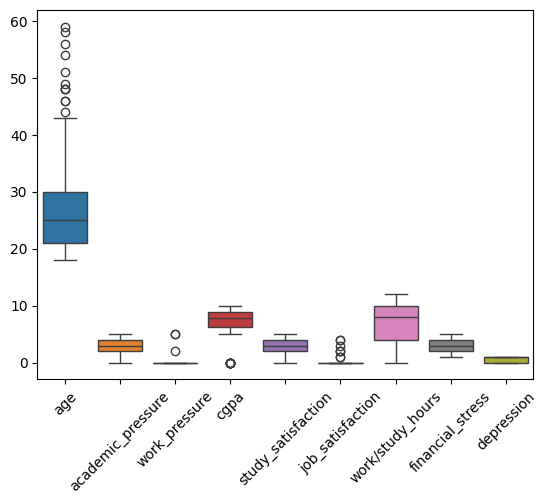

In [ ]:
sns.boxplot(stud_d[['age', 'academic'job_satisfaction'_pressure', 'work_pressure', 'cgpa',
       'study_satisfaction', , 'work/study_hours',
       'financial_stress', 'depression']])

plt.xticks(rotation=45)

plt.show()

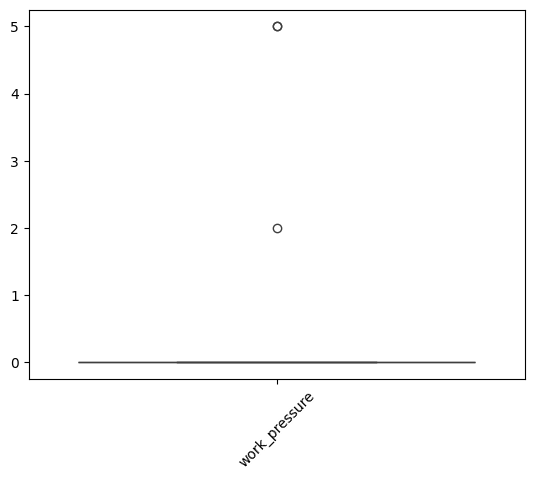

In [ ]:
sns.boxplot(stud_d[[ 'work_pressure']])

plt.xticks(rotation=45)

plt.show()

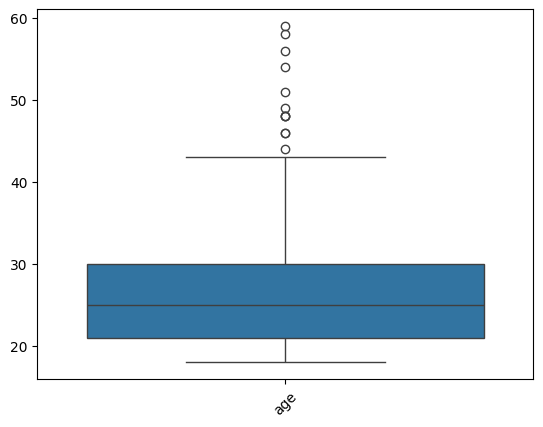

In [ ]:
sns.boxplot(stud_d[['age']])

plt.xticks(rotation=45)

plt.show()

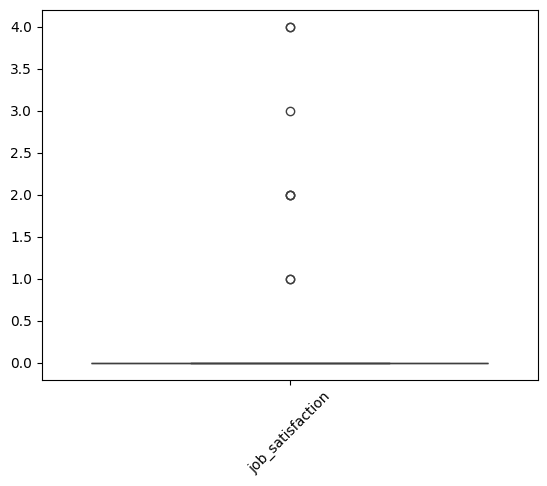

In [ ]:
sns.boxplot(stud_d[[
       'job_satisfaction']])

plt.xticks(rotation=45)

plt.show()

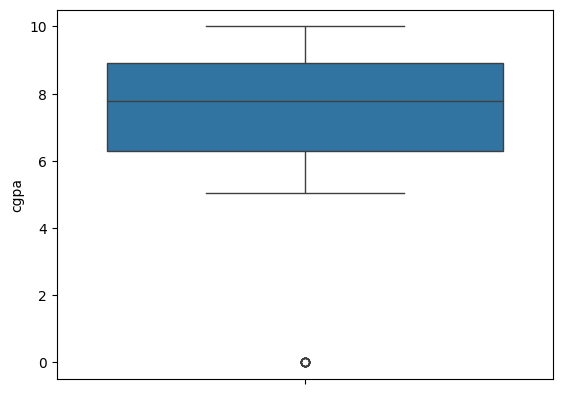

In [ ]:
sns.boxplot(stud_d[ 'cgpa'])

plt.xticks(rotation=45)

plt.show()

#outlier handling method

###using IQR method

In [ ]:
q1 = stud_d['age'].quantile(.25)
q2 = stud_d['age'].quantile(.50)
q3 = stud_d['age'].quantile(.75)

print(f'Q1 = {q1}\nQ2 = {q2}\nQ3 = {q3}')


iqr = q3-q1
up_lim = q3+(1.5*iqr)
low_lim = q1-(1.5*iqr)
print(f'IQR = {iqr}\nUp_lim = {up_lim}\nLow_lim = {low_lim}')

Q1 = 21.0
Q2 = 25.0
Q3 = 30.0
IQR = 9.0
Up_lim = 43.5
Low_lim = 7.5


In [ ]:
stud_d.loc[stud_d['age']>up_lim,'age'] =up_lim
stud_d.loc[stud_d['age']<low_lim,'age'] =low_lim

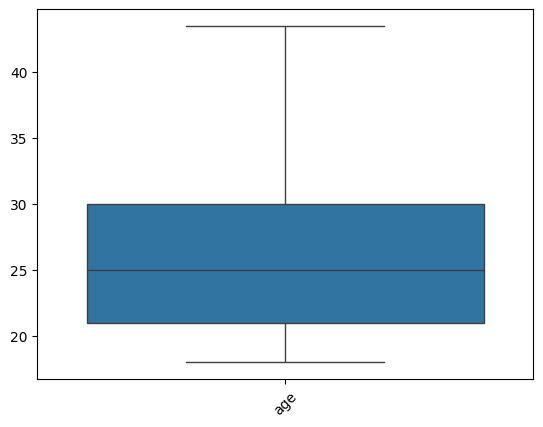

In [ ]:
sns.boxplot(stud_d[[ 'age']])

plt.xticks(rotation=45)

plt.show()

In [ ]:
q1 = stud_d['work_pressure'].quantile(.25)
q2 = stud_d['work_pressure'].quantile(.50)
q3 = stud_d['work_pressure'].quantile(.75)

print(f'Q1 = {q1}\nQ2 = {q2}\nQ3 = {q3}')


iqr = q3-q1
up_lim = q3+(1.5*iqr)
low_lim = q1-(1.5*iqr)
print(f'IQR = {iqr}\nUp_lim = {up_lim}\nLow_lim = {low_lim}')

Q1 = 0.0
Q2 = 0.0
Q3 = 0.0
IQR = 0.0
Up_lim = 0.0
Low_lim = 0.0


In [ ]:
stud_d.loc[stud_d['work_pressure']>up_lim,'work_pressure'] =up_lim
stud_d.loc[stud_d['work_pressure']<low_lim,'work_pressure'] =low_lim

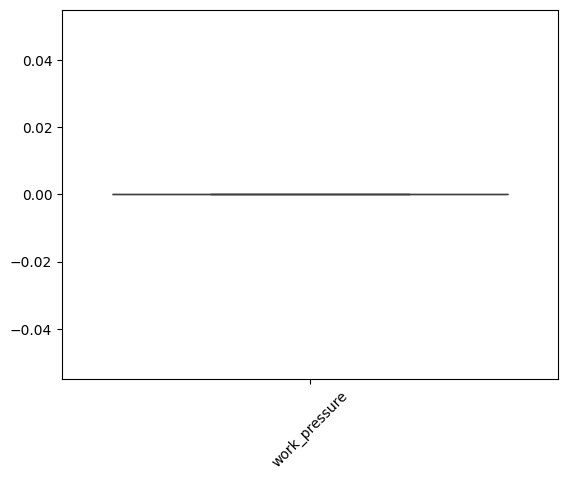

In [ ]:
sns.boxplot(stud_d[[ 'work_pressure']])

plt.xticks(rotation=45)

plt.show()

In [ ]:
q1 = stud_d['cgpa'].quantile(.25)
q2 = stud_d['cgpa'].quantile(.50)
q3 = stud_d['cgpa'].quantile(.75)

print(f'Q1 = {q1}\nQ2 = {q2}\nQ3 = {q3}')


iqr = q3-q1
up_lim = q3+(1.5*iqr)
low_lim = q1-(1.5*iqr)
print(f'IQR = {iqr}\nUp_lim = {up_lim}\nLow_lim = {low_lim}')

Q1 = 6.29
Q2 = 7.77
Q3 = 8.92
IQR = 2.63
Up_lim = 12.865
Low_lim = 2.345


In [ ]:
stud_d.loc[stud_d['cgpa']>up_lim,'cgpa'] =up_lim
stud_d.loc[stud_d['cgpa']<low_lim,'cgpa'] =low_lim

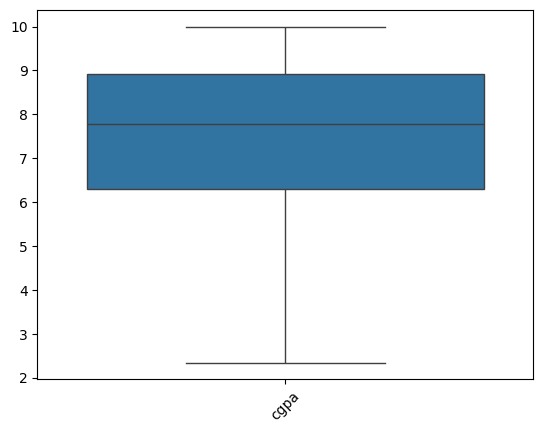

In [ ]:
sns.boxplot(stud_d[[ 'cgpa']])

plt.xticks(rotation=45)

plt.show()

In [ ]:
q1 = stud_d['job_satisfaction'].quantile(.25)
q2 = stud_d['job_satisfaction'].quantile(.50)
q3 = stud_d['job_satisfaction'].quantile(.75)

print(f'Q1 = {q1}\nQ2 = {q2}\nQ3 = {q3}')


iqr = q3-q1
up_lim = q3+(1.5*iqr)
low_lim = q1-(1.5*iqr)
print(f'IQR = {iqr}\nUp_lim = {up_lim}\nLow_lim = {low_lim}')

Q1 = 0.0
Q2 = 0.0
Q3 = 0.0
IQR = 0.0
Up_lim = 0.0
Low_lim = 0.0


In [ ]:
stud_d.loc[stud_d['job_satisfaction']>up_lim,'job_satisfaction'] =up_lim
stud_d.loc[stud_d['job_satisfaction']<low_lim,'cgpajob_satisfaction'] =low_lim

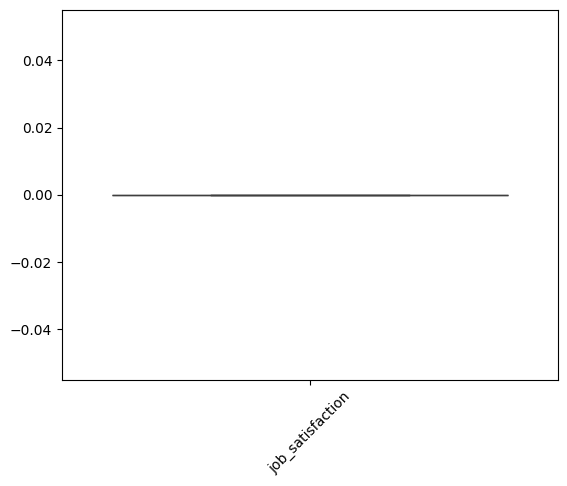

In [ ]:
sns.boxplot(stud_d[[ 'job_satisfaction']])

plt.xticks(rotation=45)

plt.show()

#Encoding

In [ ]:
stud_d.dtypes

,0
gender,object
age,float64
city,object
profession,object
academic_pressure,float64
work_pressure,float64
cgpa,float64
study_satisfaction,float64
job_satisfaction,float64
sleep_duration,object


In [ ]:
stud_d['city'].unique()

array(['Rajkot', 'Surat', 'Vasai-Virar', 'Varanasi', 'Kanpur', 'Srinagar',
       'Indore', 'Hyderabad', 'Bangalore', 'Lucknow', 'Agra', 'Vadodara',
       'Nagpur', 'Nashik', 'Ludhiana', 'Thane', 'Bhopal', 'Patna',
       'Meerut', 'Ahmedabad', 'Delhi', 'Kolkata', 'Kalyan',
       'Visakhapatnam', 'Pune', 'Mumbai', 'Ghaziabad', 'Chennai',
       'Faridabad', 'Bhavna', 'Jaipur', 'Mira', 'Reyansh', 'Kibara',
       'Vaanya', 'Rashi', 'Harsh', '3.0', 'Nalini', 'ME', 'M.Com',
       'Khaziabad', 'Saanvi', 'City', 'Nandini', 'Gaurav', 'Harsha',
       'M.Tech', 'Less Delhi', 'Less than 5 Kalyan', 'Nalyan', 'Mihir'],
      dtype=object)

In [ ]:
stud_d['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [ ]:
stud_d['sleep_duration'].unique()

array(['5-6 hours', 'More than 8 hours', 'Less than 5 hours', '7-8 hours',
       'Others'], dtype=object)

In [ ]:
stud_d['degree'].unique()

array(['Class 12', 'B.Ed', 'Others', 'MSc', 'BA', 'MA', 'B.Tech', 'BCA',
       'MCA', 'M.Com', 'M.Tech', 'BSc', 'BHM', 'B.Arch', 'M.Pharm',
       'MBBS', 'BE', 'B.Com', 'M.Ed', 'MBA', 'BBA', 'B.Pharm', 'MHM',
       'LLB', 'PhD', 'ME', 'MD', 'LLM'], dtype=object)

In [ ]:
cat_cols = stud_d.select_dtypes(include =['object'])

In [ ]:
cat_cols

,gender,city,profession,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,family_history_of_mental_illness,depression_category
0,Female,Rajkot,Student,5-6 hours,Unhealthy,Class 12,Yes,Yes,Yes
1,Male,Surat,Student,More than 8 hours,Moderate,Class 12,Yes,Yes,Yes
2,Male,Vasai-Virar,Student,Less than 5 hours,Moderate,Class 12,Yes,No,Yes
3,Male,Varanasi,Student,7-8 hours,Healthy,Class 12,Yes,Yes,Yes
4,Female,Kanpur,Student,Less than 5 hours,Healthy,Class 12,No,No,Yes
...,...,...,...,...,...,...,...,...,...
27893,Female,Bhopal,Student,Less than 5 hours,Moderate,MBBS,Yes,Yes,No
27894,Male,Agra,Student,More than 8 hours,Unhealthy,B.Ed,Yes,Yes,No
27895,Female,Ludhiana,Student,5-6 hours,Unhealthy,BSc,No,Yes,No
27896,Female,Chennai,Student,7-8 hours,Healthy,Class 12,No,No,No


In [ ]:
frequency = stud_d['city'].value_counts()

stud_d['city'] = stud_d['city'].map(frequency)
print(stud_d['city'])

0         816
1        1078
2        1290
3         684
4         609
         ... 
27893     934
27894    1094
27895    1111
27896     885
27897     547
Name: city, Length: 27898, dtype: int64


In [ ]:
frequency1 = stud_d['profession'].value_counts()

stud_d['profession'] = stud_d['profession'].map(frequency1)
print(stud_d['profession'])

0        27867
1        27867
2        27867
3        27867
4        27867
         ...  
27893    27867
27894    27867
27895    27867
27896    27867
27897    27867
Name: profession, Length: 27898, dtype: int64


In [ ]:
stud_d.dtypes

,0
gender,object
age,float64
city,int64
profession,int64
academic_pressure,float64
work_pressure,float64
cgpa,float64
study_satisfaction,float64
job_satisfaction,float64
sleep_duration,object


In [ ]:
# ordinal encoder
from sklearn.preprocessing import OrdinalEncoder
encoder= OrdinalEncoder(
    categories=[['Class 12', 'BA', 'BBA', 'BCA', 'B.Com', 'BSc',
                 'BHM', 'B.Pharm', 'B.Arch', 'B.Tech', 'BE', 'B.Ed',
                 'LLB', 'MBBS', 'MA', 'MBA', 'MCA', 'M.Com', 'MSc',
                 'MHM', 'M.Pharm', 'M.Tech', 'ME', 'M.Ed', 'LLM',
                 'MD', 'PhD', 'Others']]
)
stud_d['degree']=encoder.fit_transform(stud_d[['degree']])

In [ ]:
stud_d.dtypes

,0
gender,object
age,float64
city,int64
profession,int64
academic_pressure,float64
work_pressure,float64
cgpa,float64
study_satisfaction,float64
job_satisfaction,float64
sleep_duration,object


In [ ]:

# encoder1= OrdinalEncoder(
#     categories=[['More than 8 hours', '7-8 hours', '5-6 hours',
#                  'Less than 5 hours', 'Others']]
# )
# df_data['sleep_duration']=encoder.fit_transform(df_data[['sleep_duration']])

In [ ]:

from sklearn.preprocessing import OrdinalEncoder

# Wrap the descending list in an outer list [ ]
sleep_categories = [
    ['More than 8 hours', '7-8 hours', '5-6 hours', 'Less than 5 hours', 'Others']
]

# Initialize the encoder with the correct 2D categories shape
encoder = OrdinalEncoder(categories=sleep_categories)

# Fit and transform your column
stud_d['sleep_duration'] = encoder.fit_transform(stud_d[['sleep_duration']])


In [ ]:
stud_d

,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,work/study_hours,financial_stress,family_history_of_mental_illness,depression,depression_category,cgpajob_satisfaction
0,Female,18.0,816,27867,5.0,0.0,8.91,3.0,0.0,2.0,Unhealthy,0.0,Yes,10.0,2.0,Yes,1,Yes,NaN
1,Male,18.0,1078,27867,5.0,0.0,7.83,5.0,0.0,0.0,Moderate,0.0,Yes,8.0,5.0,Yes,1,Yes,NaN
2,Male,18.0,1290,27867,4.0,0.0,8.70,5.0,0.0,3.0,Moderate,0.0,Yes,2.0,4.0,No,1,Yes,NaN
3,Male,18.0,684,27867,4.0,0.0,9.19,5.0,0.0,1.0,Healthy,0.0,Yes,12.0,3.0,Yes,1,Yes,NaN
4,Female,18.0,609,27867,1.0,0.0,7.27,5.0,0.0,3.0,Healthy,0.0,No,7.0,5.0,No,1,Yes,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27893,Female,43.5,934,27867,2.0,0.0,8.26,3.0,0.0,3.0,Moderate,13.0,Yes,5.0,5.0,Yes,0,No,NaN
27894,Male,43.5,1094,27867,5.0,0.0,9.60,2.0,0.0,0.0,Unhealthy,11.0,Yes,9.0,3.0,Yes,0,No,NaN
27895,Female,43.5,1111,27867,3.0,0.0,7.94,5.0,0.0,2.0,Unhealthy,5.0,No,1.0,5.0,Yes,0,No,NaN
27896,Female,43.5,885,27867,4.0,0.0,8.58,1.0,0.0,1.0,Healthy,0.0,No,4.0,4.0,No,0,No,NaN


In [ ]:
stud_d['dietary_habits'].unique()

array(['Unhealthy', 'Moderate', 'Healthy', 'Others'], dtype=object)

In [ ]:
diet_categories = [
    ['Unhealthy', 'Moderate', 'Healthy', 'Others']
]

# Initialize the encoder with the correct 2D categories shape
encoder = OrdinalEncoder(categories=diet_categories )

# Fit and transform your column
stud_d['dietary_habits'] = encoder.fit_transform(stud_d[['dietary_habits']])

In [ ]:
# label encoder

from sklearn.preprocessing import LabelEncoder

binary_cols = ['gender','have_you_ever_had_suicidal_thoughts_?',
               'family_history_of_mental_illness','depression_category']
le = LabelEncoder()
for col in binary_cols:
    stud_d[col] = le.fit_transform(stud_d[col])

In [ ]:
stud_d.dtypes

,0
gender,int64
age,float64
city,int64
profession,int64
academic_pressure,float64
work_pressure,float64
cgpa,float64
study_satisfaction,float64
job_satisfaction,float64
sleep_duration,float64


#Scalling

In [ ]:
from sklearn.model_selection import train_test_split

y = stud_d['depression']
x = stud_d.drop('depression',axis=1)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
x_train_scaled

array([[-1.12343772,  1.46879872, -0.43398838, ...,  1.03039265,
        -1.18848473,         nan],
       [-1.12343772,  0.65119363,  1.39206322, ..., -0.97050382,
         0.84140753,         nan],
       [ 0.890125  ,  0.24239108,  0.02346192, ..., -0.97050382,
         0.84140753,         nan],
       ...,
       [ 0.890125  , -1.59722039,  1.39206322, ..., -0.97050382,
         0.84140753,         nan],
       [-1.12343772,  0.24239108,  0.24093829, ..., -0.97050382,
         0.84140753,         nan],
       [ 0.890125  ,  1.26439745, -1.46887594, ...,  1.03039265,
        -1.18848473,         nan]])

In [ ]:
x_test_scaled

array([[-1.12343772,  0.24239108,  0.28968299, ..., -0.97050382,
        -1.18848473,         nan],
       [ 0.890125  ,  0.65119363, -1.1876565 , ..., -0.97050382,
         0.84140753,         nan],
       [-1.12343772,  1.6732    , -0.43398838, ...,  1.03039265,
        -1.18848473,         nan],
       ...,
       [-1.12343772,  0.8555949 ,  0.24093829, ...,  1.03039265,
        -1.18848473,         nan],
       [ 0.890125  ,  1.05999618, -1.13141261, ..., -0.97050382,
        -1.18848473,         nan],
       [ 0.890125  , -0.77961529,  0.34967648, ..., -0.97050382,
         0.84140753,         nan]])